<a href="https://colab.research.google.com/github/supriyamishra0702-supmi/Amazon_Music_Clustering-/blob/main/Amazon_Music_Clustering_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


In [ ]:
# 1. Load Dataset
df = pd.read_csv('single_genre_artists.csv')



In [ ]:
# 2. Initial Exploration
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  object 
 1   name_song           95837 non-null  object 
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  object 
 6   release_date        95837 non-null  object 
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  vale

In [ ]:
print(df.columns.tolist())


['id_songs', 'name_song', 'popularity_songs', 'duration_ms', 'explicit', 'id_artists', 'release_date', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'genres', 'name_artists', 'popularity_artists']


In [ ]:
# 1. Separate Metadata (for reference later)
metadata_cols = ['id_songs', 'name_song', 'name_artists', 'genres', 'release_date']
metadata = df[metadata_cols]

In [ ]:
# 2. Select Audio Features (The math for clustering)
feature_cols = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'
]
X = df[feature_cols]

In [ ]:
X

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.563,0.1840,-13.757,0.0512,0.993,0.000016,0.3250,0.654,133.088,161427
1,0.427,0.1800,-15.375,0.0670,0.989,0.000000,0.1280,0.431,78.459,223440
2,0.511,0.2060,-15.514,0.0592,0.995,0.000000,0.4180,0.481,70.443,208267
3,0.676,0.4670,-12.393,0.1650,0.991,0.000000,0.2190,0.726,129.775,161933
4,0.650,0.2980,-13.806,0.1380,0.991,0.000000,0.3730,0.844,75.950,167973
...,...,...,...,...,...,...,...,...,...,...
95832,0.674,0.5680,-6.356,0.0408,0.116,0.000000,0.1650,0.640,166.107,174800
95833,0.528,0.6730,-3.639,0.0314,0.143,0.000000,0.0989,0.297,130.066,265846
95834,0.609,0.0172,-28.573,0.1180,0.996,0.973000,0.1080,0.890,68.619,82500
95835,0.562,0.0331,-25.551,0.1030,0.996,0.961000,0.1110,0.386,63.696,185250


In [ ]:
# 3. Handle Missing Values
X = X.fillna(X.mean())

In [ ]:

X

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.563,0.1840,-13.757,0.0512,0.993,0.000016,0.3250,0.654,133.088,161427
1,0.427,0.1800,-15.375,0.0670,0.989,0.000000,0.1280,0.431,78.459,223440
2,0.511,0.2060,-15.514,0.0592,0.995,0.000000,0.4180,0.481,70.443,208267
3,0.676,0.4670,-12.393,0.1650,0.991,0.000000,0.2190,0.726,129.775,161933
4,0.650,0.2980,-13.806,0.1380,0.991,0.000000,0.3730,0.844,75.950,167973
...,...,...,...,...,...,...,...,...,...,...
95832,0.674,0.5680,-6.356,0.0408,0.116,0.000000,0.1650,0.640,166.107,174800
95833,0.528,0.6730,-3.639,0.0314,0.143,0.000000,0.0989,0.297,130.066,265846
95834,0.609,0.0172,-28.573,0.1180,0.996,0.973000,0.1080,0.890,68.619,82500
95835,0.562,0.0331,-25.551,0.1030,0.996,0.961000,0.1110,0.386,63.696,185250


In [ ]:
# 4. Feature Scaling (CRITICAL for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data is cleaned and scaled. Ready for clustering!")

Data is cleaned and scaled. Ready for clustering!


In [ ]:
X_scaled

array([[-0.15347598, -1.51112816, -0.75790895, ...,  0.32128698,
         0.51500516, -0.40173462],
       [-1.02851842, -1.52805562, -1.09862851, ..., -0.57745518,
        -1.2944868 ,  0.12490637],
       [-0.48805103, -1.41802711, -1.12789922, ..., -0.37594348,
        -1.56000306, -0.00394925],
       ...,
       [ 0.14249425, -2.21700341, -3.87787243, ...,  1.27242218,
        -1.62041993, -1.07201656],
       [-0.15991012, -2.14971674, -3.24149759, ..., -0.7588157 ,
        -1.78348586, -0.19941949],
       [-0.17277839, -0.09768491,  0.56580125, ..., -1.46410663,
         0.47552221,  0.4206722 ]])

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

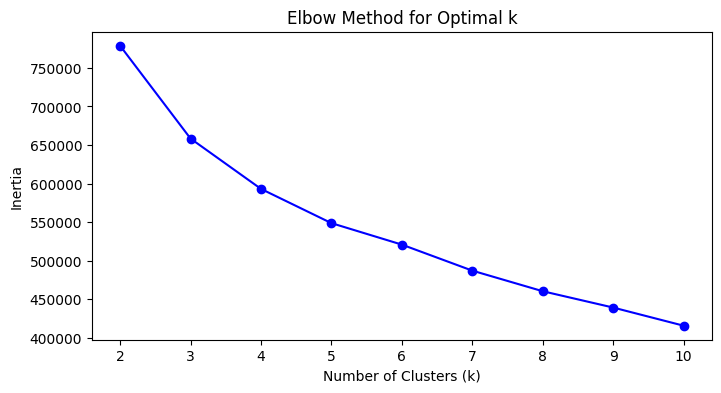

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score


In [ ]:
# 1. Fit the final model
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster_label'] = kmeans.fit_predict(X_scaled)

In [ ]:
# 2. Calculate Silhouette Score
# Higher score (closer to 1) means better defined clusters
sil_score = silhouette_score(X_scaled, df['cluster_label'])

print(f"Final Cluster Count: {optimal_k}")
print(f"Silhouette Score: {sil_score:.4f}")



Final Cluster Count: 5
Silhouette Score: 0.1864


In [ ]:
# 3. Quick peek at the results
print(df[['name_song', 'name_artists', 'cluster_label']].head(10))

          name_song name_artists  cluster_label
0           La Java  Mistinguett              3
1          En Douce  Mistinguett              3
2     J'en Ai Marre  Mistinguett              3
3  Ils n'ont pas ca  Mistinguett              3
4         La belote  Mistinguett              3
5   Oh mademoiselle  Mistinguett              3
6    Il m'a vue nue  Mistinguett              3
7      Mon Bus'ness  Mistinguett              3
8    Ça c'est Paris  Mistinguett              3
9           Le Fado  Mistinguett              3


In [ ]:
# Calculate the mean of each feature per cluster
interpretation = df.groupby('cluster_label')[feature_cols].mean()


In [ ]:
# Display the summary
print(interpretation)


               danceability    energy   loudness  speechiness  acousticness  \
cluster_label                                                                 
0                  0.706962  0.671949  -7.986034     0.078149      0.309603   
1                  0.484072  0.400033 -14.207328     0.059369      0.668444   
2                  0.664406  0.466487 -13.387732     0.838939      0.586096   
3                  0.503925  0.313460 -12.634777     0.062285      0.743712   
4                  0.502056  0.711780  -7.072090     0.072693      0.193385   

               instrumentalness  liveness   valence       tempo    duration_ms  
cluster_label                                                                   
0                      0.021395  0.171255  0.786520  117.845522  213629.943898  
1                      0.817177  0.185157  0.449815  113.510101  227500.961738  
2                      0.000879  0.435634  0.583226  100.176056   96210.790434  
3                      0.018421  0.179605

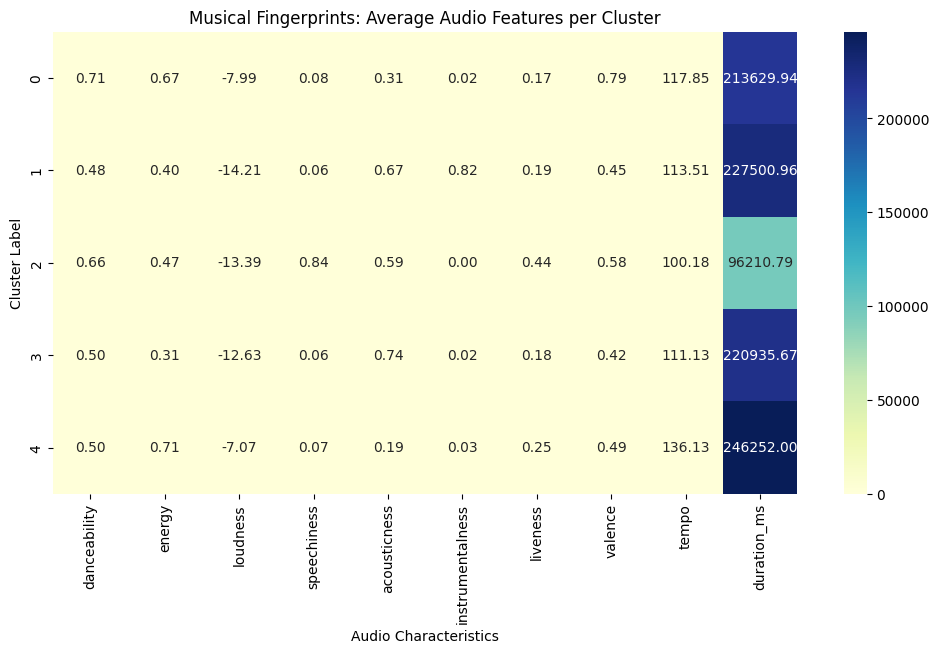

In [ ]:
# Create a heatmap to visualize the "musical fingerprint" of each cluster
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(interpretation, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Musical Fingerprints: Average Audio Features per Cluster')
plt.ylabel('Cluster Label')
plt.xlabel('Audio Characteristics')
plt.show()


In [ ]:
#visualization (PCA)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)




In [ ]:
df['pca_x'] = pca_data[:, 0]
df['pca_y'] = pca_data[:, 1]

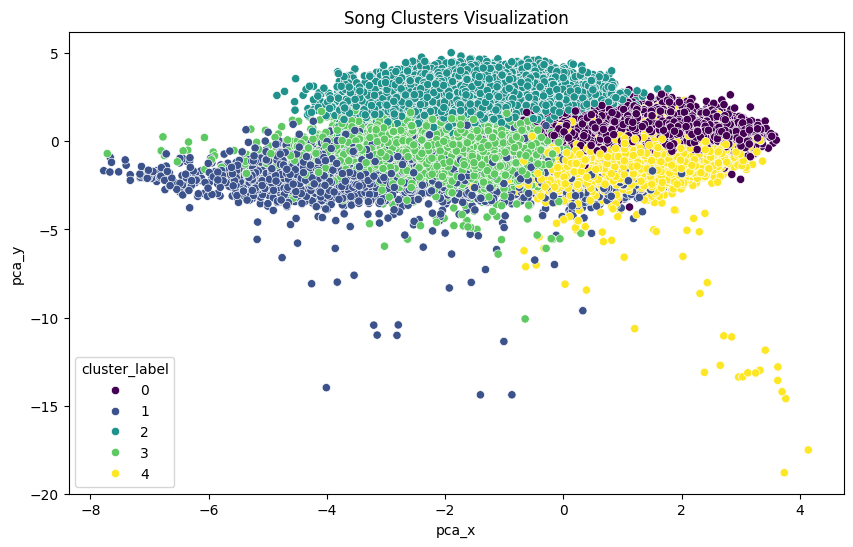

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='pca_x', y='pca_y', hue='cluster_label', palette='viridis')
plt.title('Song Clusters Visualization')
plt.show()


In [ ]:
# --- Distribution Plots  ---
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_3483/1373248794.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='cluster_label', y='energy', data=df, palette='viridis')
/tmp/ipykernel_3483/1373248794.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='cluster_label', y='danceability', data=df, palette='viridis')


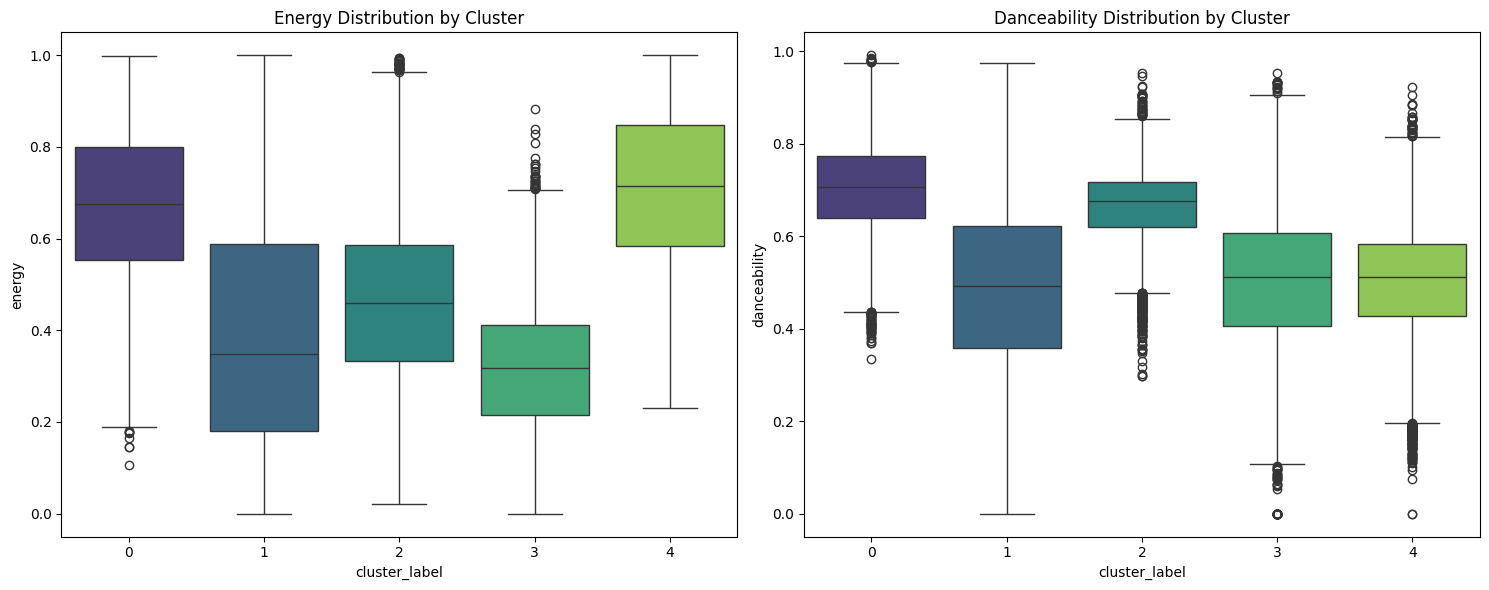

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Energy Distribution
sns.boxplot(ax=axes[0], x='cluster_label', y='energy', data=df, palette='viridis')
axes[0].set_title('Energy Distribution by Cluster')

# Plot 2: Danceability Distribution
sns.boxplot(ax=axes[1], x='cluster_label', y='danceability', data=df, palette='viridis')
axes[1].set_title('Danceability Distribution by Cluster')

plt.tight_layout()
plt.show()